In [1]:
# prompt: mount

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


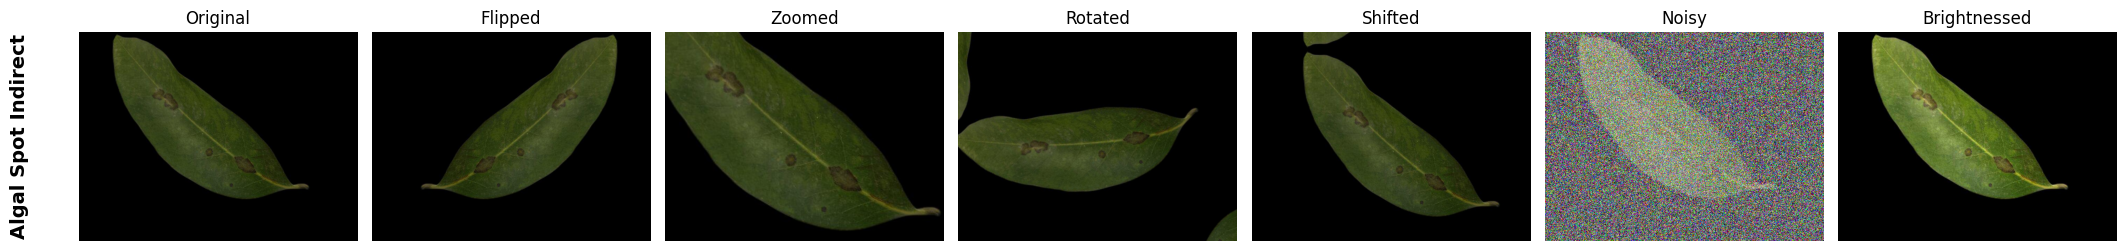

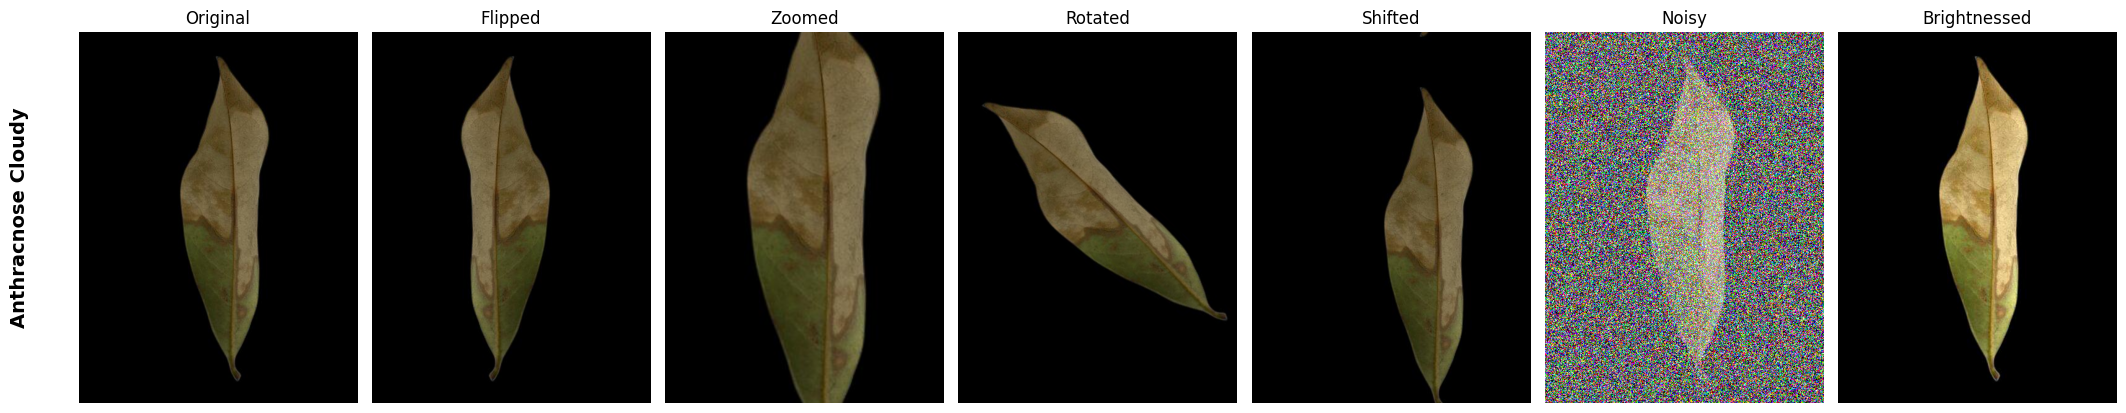

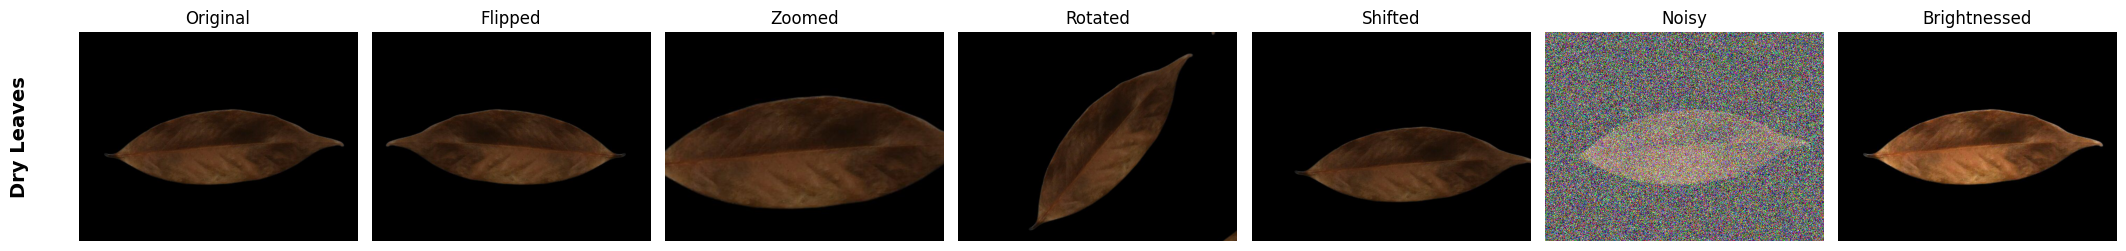

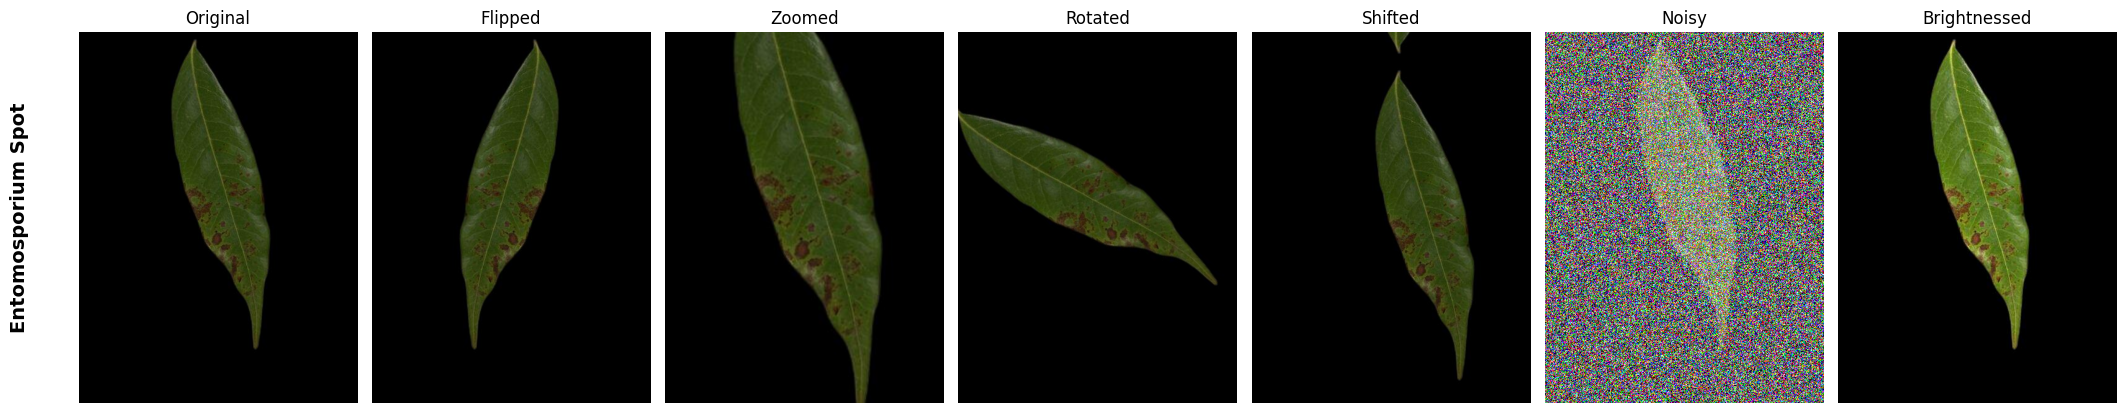

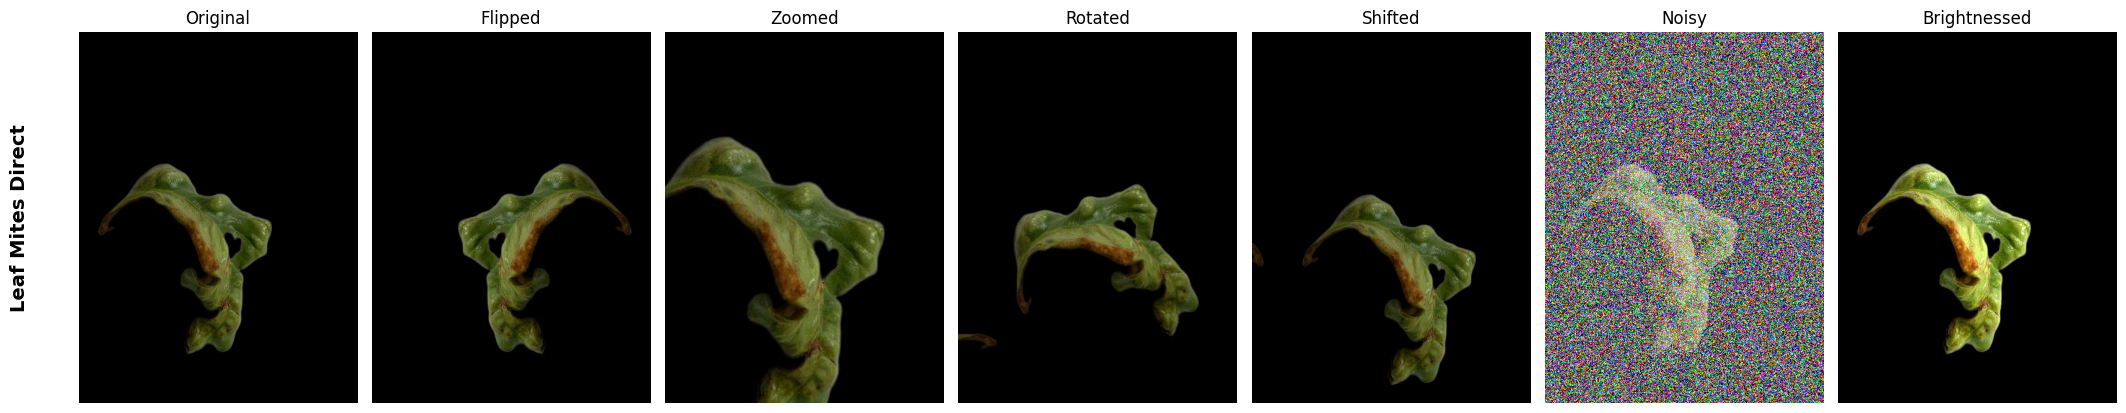

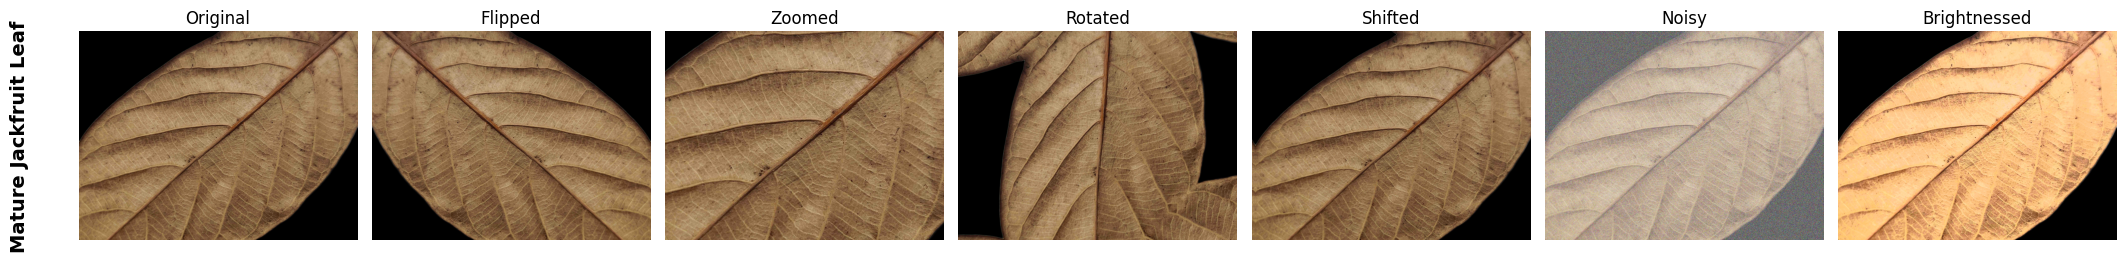

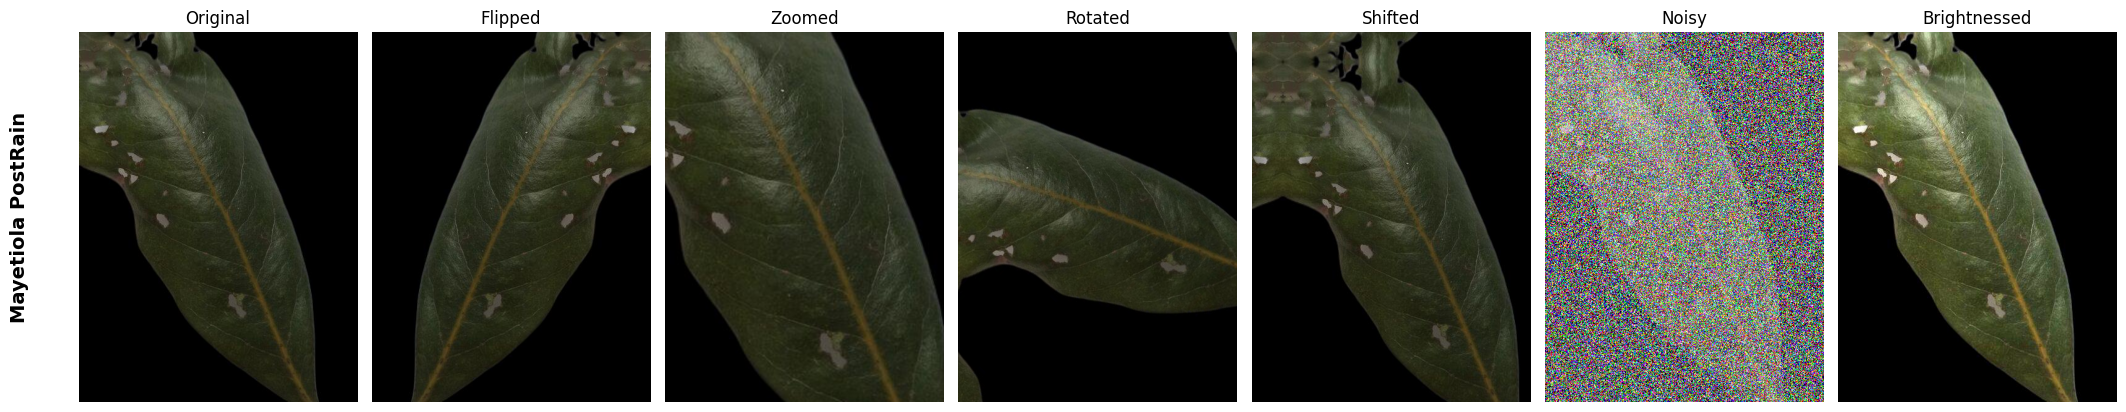

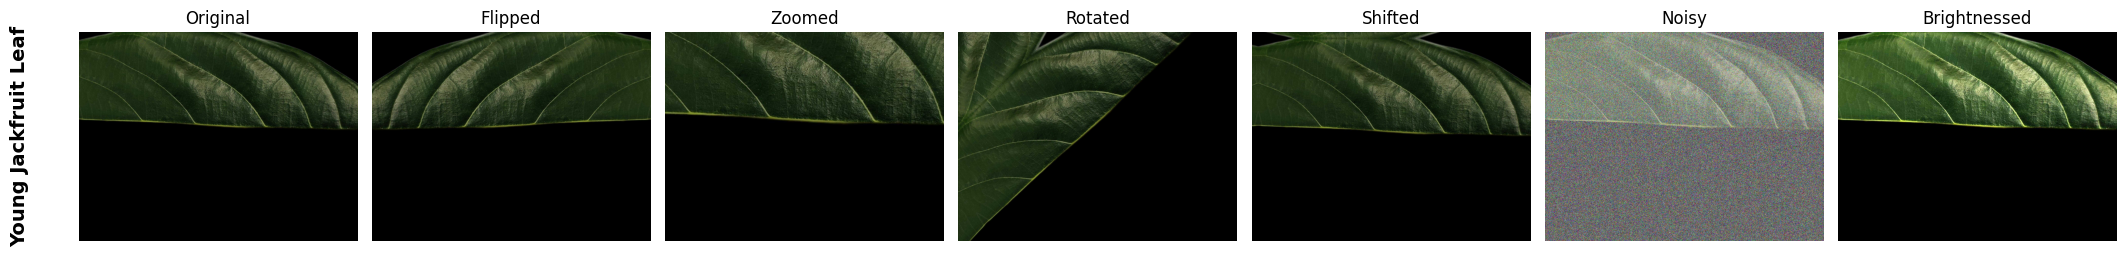

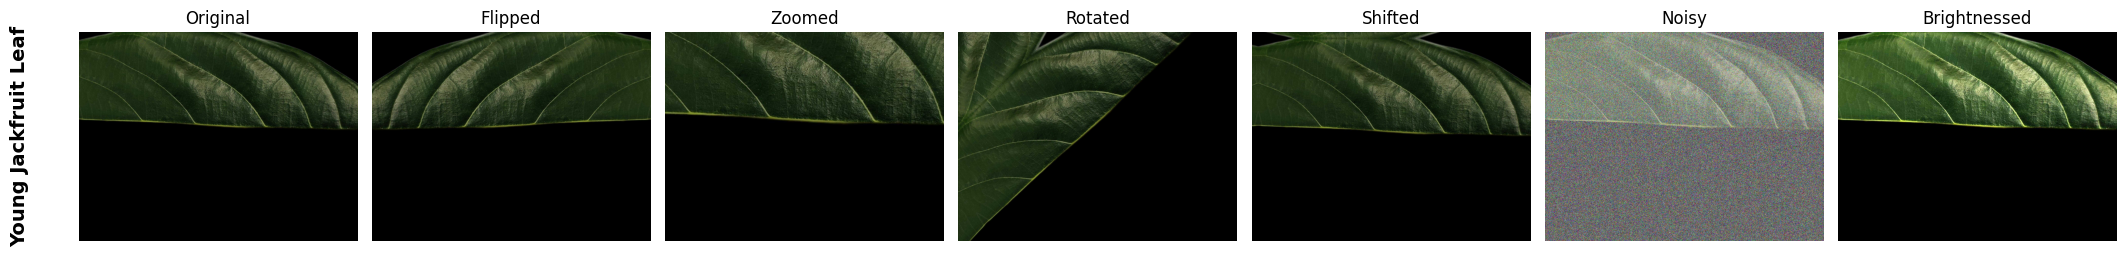

In [4]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# ✅ Image folder path
image_class_paths = {
    'Algal Spot Indirect': '/Users/shahariar13/Documents/Summer_25/Paper/DataInBrief/Combined_Litchi_Jackfruit/Lychee & Jackfruit images/Algal Spot Indirect',
    'Anthracnose Cloudy': '/Users/shahariar13/Documents/Summer_25/Paper/DataInBrief/Combined_Litchi_Jackfruit/Lychee & Jackfruit images/Anthracnose Cloudy',
    'Dry Leaves': '/Users/shahariar13/Documents/Summer_25/Paper/DataInBrief/Combined_Litchi_Jackfruit/Lychee & Jackfruit images/Dry Leaves',
    'Entomosporium Spot': '/Users/shahariar13/Documents/Summer_25/Paper/DataInBrief/Combined_Litchi_Jackfruit/Lychee & Jackfruit images/Entomosporium Spot',
    'Leaf Mites Direct': '/Users/shahariar13/Documents/Summer_25/Paper/DataInBrief/Combined_Litchi_Jackfruit/Lychee & Jackfruit images/Leaf Mites Direct',
    'Mature Jackfruit Leaf': '/Users/shahariar13/Documents/Summer_25/Paper/DataInBrief/Combined_Litchi_Jackfruit/Lychee & Jackfruit images/Mature Jackfruit Leaf',
    'Mayetiola PostRain': '/Users/shahariar13/Documents/Summer_25/Paper/DataInBrief/Combined_Litchi_Jackfruit/Lychee & Jackfruit images/Mayetiola PostRain',
    'Young Jackfruit Leaf': '/Users/shahariar13/Documents/Summer_25/Paper/DataInBrief/Combined_Litchi_Jackfruit/Lychee & Jackfruit images/Young Jackfruit Leaf',
}

# 🔧 Augmentation functions
def flip_image(img): return cv2.flip(img, 1)

def zoom_image(img, zoom_factor=1.5):
    h, w = img.shape[:2]
    new_h, new_w = int(h / zoom_factor), int(w / zoom_factor)
    y1, x1 = (h - new_h) // 2, (w - new_w) // 2
    cropped = img[y1:y1 + new_h, x1:x1 + new_w]
    return cv2.resize(cropped, (w, h))

def rotate_image(img, angle=45):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def shift_image(img, shift_val=50):
    M = np.float32([[1, 0, shift_val], [0, 1, shift_val]])
    return cv2.warpAffine(img, M, (img.shape[1], img.shape[0]), borderMode=cv2.BORDER_REFLECT)

def add_noise(img):
    noise = np.random.normal(0, 5, img.shape).astype(np.uint8)
    return cv2.add(img, noise)

def adjust_brightness(img, factor=1.8):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[..., 2] *= factor
    hsv[..., 2] = np.clip(hsv[..., 2], 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

# 📂 Process each class folder
for label, folder_path in image_class_paths.items():
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if len(image_files) == 0:
        print(f"❌ No images found in folder: {folder_path}")
        continue

    first_image_path = os.path.join(folder_path, image_files[0])
    img_bgr = cv2.imread(first_image_path)

    if img_bgr is None:
        print(f"❌ Failed to read image: {first_image_path}")
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    aug_images = {
        "Original": img_rgb,
        "Flipped": flip_image(img_rgb),
        "Zoomed": zoom_image(img_rgb),
        "Rotated": rotate_image(img_rgb),
        "Shifted": shift_image(img_rgb),
        "Noisy": add_noise(img_rgb),
        "Brightnessed": adjust_brightness(img_rgb)
    }

    # ✅ THIS BLOCK SHOULD BE INSIDE THE LOOP
    fig, axs = plt.subplots(1, 7, figsize=(22, 5))
    for idx, (title, image) in enumerate(aug_images.items()):
        axs[idx].imshow(image)
        axs[idx].set_title(title)
        axs[idx].axis('off')

    fig.text(0.04, 0.5, label, va='center', ha='center', rotation='vertical',
             fontsize=14, color='black', fontweight='bold')

    plt.tight_layout(rect=[0.06, 0, 1, 1])
    plt.show()


    # 📊 Show augmented images with class name (only name, black color)
fig, axs = plt.subplots(1, 7, figsize=(22, 5))
for idx, (title, image) in enumerate(aug_images.items()):
    axs[idx].imshow(image)
    axs[idx].set_title(title)
    axs[idx].axis('off')

# ➕ Show only class name (black color), no "Class:" prefix
fig.text(0.04, 0.5, label, va='center', ha='center', rotation='vertical',
         fontsize=14, color='black', fontweight='bold')

plt.tight_layout(rect=[0.06, 0, 1, 1])  # make room for left-side label
plt.show()
